In [3]:
import numpy as np
import gymnasium as gym
import importlib
import envs

import learners
import analysis
importlib.reload(analysis)
importlib.reload(learners)
from learners import *
from analysis import *

def scheduler(alpha, t): return alpha / (0.5*t+1)**0.5
def get_scheduler(val): return lambda alpha, t: alpha / (val*t+1)**0.5

params = Params(
    model_name="CliffWindy",
    n_runs=1,
    n_episodes=20_000,
    save_skip=100,
    lr_decay=None,
    seed=123,
    
    N=32,
    # alpha=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.2,1.5,1.8,2.0,5.0],
    alpha=1.0,
    gamma=0.90,
    epsilon=0.1,
    kappa=0.0,
    
    nA=None,
    nS=None,
    shape=None,
)
rng = np.random.default_rng(params.seed)
tau = (np.arange(params.N) + 0.5) / params.N
env = gym.make(
    params.model_name,
    shape=(3,5),
)
params = params._replace(nA=int(env.action_space.n))
params = params._replace(nS=int(env.observation_space.n))
params = params._replace(shape=env.unwrapped.shape)
s_init, _ = env.reset()

save_to = None
# save_to = "experiments/"+params.model_name

In [5]:
policy, V_pi = PolicyIteration(env, params.gamma)
explorer = EpsilonGreedy(rng)

def get_exp_scheduler(alpha, n_ep_decay, min_val=0.005): return lambda t: max(alpha * 0.5**(t/n_ep_decay), min_val)

table_qr = QR(params, policy).train(env, explorer, get_exp_scheduler(0.5, 2000))
# table_q = Qlearner(params, policy).train(env, explorer, get_exp_scheduler(0.5, 2000))

100%|██████████| 20000/20000 [00:26<00:00, 759.18it/s, run=1, t=2e+4] 


In [6]:
returns = MonteCarlo(env, policy, params.gamma, total_episodes=50_000)
tau_returns = np.quantile(np.sort(returns), tau)

100%|██████████| 50000/50000 [00:03<00:00, 12573.39it/s]


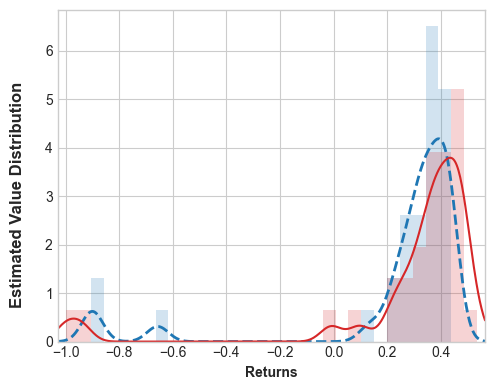

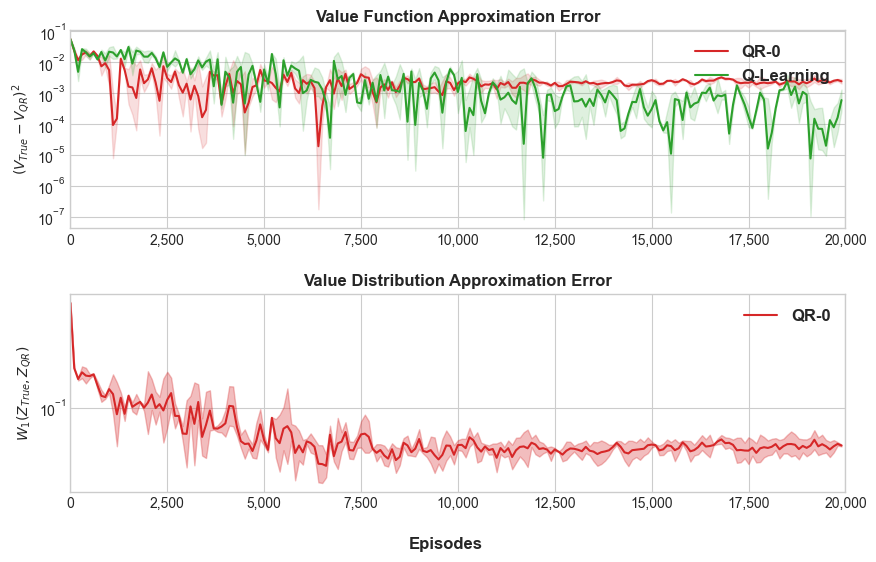

In [ ]:
def get_q(table): return table[:,:,s_init].max(2)
def get_best(table): return get_q(table)[:,-1].mean(0)

plot_objs = [
    (get_best(table_qr), "QR-0"),
]
plot_qs = [
    (get_q(table_qr), "QR-0"),
    # (get_q(table_q), "Q-Learning"),
]
plot_pdf(plot_objs, tau_returns, bandwidth=0.04, show_hist=True, N=params.N, save_to=save_to)
plot_metrics(plot_qs, tau_returns, save_skip=params.save_skip, save_to=save_to, alphas=[0.15,0.3])

In [7]:
import old.testing.display_qtables
importlib.reload(old.testing.display_qtables)
from old.testing.display_qtables import *

t_states = env.unwrapped._is_terminal.flatten()
display_qtables(table_qr.mean((0,-1)), params, highlight_optimal=False, decimals=2, margin=35, terminal_states=t_states)

In [8]:
# pa0 = policy.copy()
# pa1 = policy.copy()
# pa2 = policy.copy()
# pa3 = policy.copy()
# pa0[s_init] = (np.arange(params.nA) == 0).astype(float)
# pa1[s_init] = (np.arange(params.nA) == 1).astype(float)
# pa2[s_init] = (np.arange(params.nA) == 2).astype(float)
# pa3[s_init] = (np.arange(params.nA) == 3).astype(float)

returns0 = MonteCarlo(env, policy, params.gamma, a_init=0, total_episodes=10_000)
returns1 = MonteCarlo(env, policy, params.gamma, a_init=1, total_episodes=10_000)
returns2 = MonteCarlo(env, policy, params.gamma, a_init=2, total_episodes=10_000)
returns3 = MonteCarlo(env, policy, params.gamma, a_init=3, total_episodes=10_000)

100%|██████████| 10000/10000 [00:00<00:00, 12106.39it/s]


In [9]:
tau_returns0 = np.quantile(np.sort(returns0), tau)
tau_returns1 = np.quantile(np.sort(returns1), tau)
tau_returns2 = np.quantile(np.sort(returns2), tau)
tau_returns3 = np.quantile(np.sort(returns3), tau)

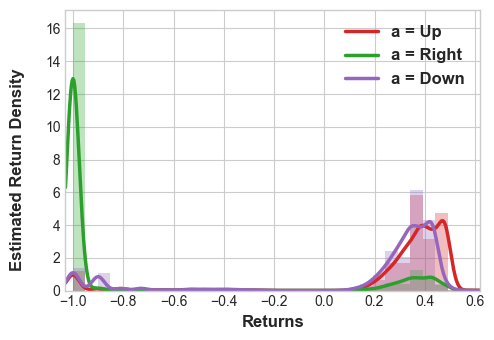

In [10]:
import analysis
importlib.reload(analysis)
from analysis import *

plot_objs = [
    (returns0, "a = Up"),
    (returns1, "a = Right"),
    (returns2, "a = Down"),
    # (returns3, "a = Up"),
    
    # (get_best(table_qr[:,:,:,0:1]), "a = Up"),
    # (get_best(table_qr[:,:,:,1:2]), "a = Right"),
    # (get_best(table_qr[:,:,:,2:3]), "a = Down"),
    # (get_best(table_qr[:,:,:,3:4]), "Left"),
]
plot_pdf(
    plot_objs,
    bandwidth=0.025,
    N=params.N,
    save_to="mini_cliff_s_init_quantiles",
    show_hist=True,
    hist_alpha=0.3,
    include_legend=True,
    linewidth=2.5,
    figsize=(5,3.5),
    x_spacing=0.03,
    ylabel="Estimated Return Density",
)